# 最適Route 探索を題材にした最適化問題を解く方法
配送Route の最適化問題を解く Algorithm を作る

## 数理最適化問題の解き方を理解しよう
### 何かを「最適化」する場合の Step
1. 問題を作る（内定化）
2. 解く

### Step1. 内定化（問題を作る）
最適化したいものを明確にする。


例). 配送最適化問題
- 総移動距離を最小にする
- 総配送Cost を最小にする

といった具合に、最小化するものを決定する。

### Step2. 問題を解く方法
大きく２通りの方法が考えられる
1. あらゆる Pattern を計算したうえで内定化した通り、総移動距離や総配送Cost が最小になる Route を選択する。
2. Heuristic.

#### 1. あらゆる Pattern を計算したうえで内定化した通り、総移動距離や総配送Cost が最小になる Route を選択する。
- Merit: 確実に正しい答えが導き出せる
- Demerit: すべての Route を計算するために、非常に時間がかかる

#### 2. Heuristic.
経験的に効率よく最適解にたどり着くと考えられている方法で、
- 特殊解法: 問題ごとに知られている方法（決まった問題に対して効果を発揮）
- 一般解法: 多くの最適化問題に適用できる方法（内定化した問題があまり知られていない場合に試すことになる）

がある。

- Merit: 高速計算が可能。
- Demerit: 厳密な最適解を導き出すことはできず、**「おおよそ最適に近い解」** になる。

## 数理最適化の出発点である「内定化」を理解しよう
数理最適化問題の解を求めるときに重要なのは、
- 目的: その問題において何を求めればよいのか
- 条件：それを取り巻くさまざまな条件

を明確に理解しておくこと。この Process を経て問題を数式化することを **「内定化」** と呼ぶ。

### 配送Route の最適化問題を内定化
- 目的: 配送Route の総移動距離を最小化する。
- 条件: 全倉庫間の距離は既知、各倉庫への訪問回数は１度のみ

移動距離を最小化する問題は **「巡回Salesman 問題」** という有名な問題として知られている。
最も基本的な巡回Salesman 問題を扱っていく。

## 全検索を行なってみよう

### 全検索
- 最適化問題を解く際の基本。
- 総当たり法、 brute-force とも呼ばれる。
- 計算に膨大な時間がかかるが、確実に最適解を求めることができる。

Start からすべての頂点を一度だけ通って再び Start地点に戻ってくるような経路をすべて列挙し、それぞれの距離を求めてその中で最も距離が短くなるような経路が回答となる。

まずは各倉庫を頂点とする Graph を可視化してみる。

倉庫の座標
[[ 9 25]
 [68 88]
 [80 49]
 [11 95]
 [53 99]
 [54 67]
 [99 15]
 [35 25]]
倉庫の位置関係


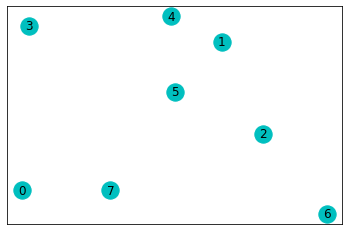

In [10]:
# 各倉庫を頂点とする Graph
import numpy as np

np.random.seed(100)
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 頂点数を８とする
n = 8

# 各地点の座標を読み込む
vertices = pd.read_csv('data/Chapter4/vertices.csv').values
print('倉庫の座標')
print(vertices)

# Graph の作成
g = nx.DiGraph()

# n個の頂点を Graph に追加
g.add_nodes_from(range(n))

# 頂点座標の情報を Graph に追加しやすい形に整形
pos = dict(enumerate(zip(vertices[:, 0], vertices[:, 1])))

# Graph を描画
nx.draw_networkx(g, pos=pos, node_color='c')
print('倉庫の位置関係')
plt.show()

６つの Step をで Graph表現を用いて、Route を可視化。

1. 倉庫(頂点)の数を決める。
2. 各倉庫の座標を決める。
3. Graph の作成を宣言
4. 倉庫(頂点)を、Graph に追加
5. 整形し、描画

In [11]:
# 距離を求める

# 頂点感の距離を Matrix で表す
graph = np.linalg.norm(
    vertices[:, None] - vertices[None, :],
    axis=-1,
)
# graph(5, 3) は、頂点５から頂点３への距離
# graph(0, 7) は、頂点０から頂点７への距離

# わかりやすさのため小数点以下は切り捨て
graph = graph.astype(int)
print('倉庫間距離の Matrix')
print(graph)

倉庫間距離の Matrix
[[  0  86  74  70  86  61  90  26]
 [ 86   0  40  57  18  25  79  71]
 [ 74  40   0  82  56  31  38  51]
 [ 70  57  82   0  42  51 118  74]
 [ 86  18  56  42   0  32  95  76]
 [ 61  25  31  51  32   0  68  46]
 [ 90  79  38 118  95  68   0  64]
 [ 26  71  51  74  76  46  64   0]]


描画した倉庫(頂点)をたどって、各頂点間の距離を算出。
１行目２列目は０番倉庫(頂点)と１番倉庫(頂点)との距離、というふうに見る。

これら、各頂点間の距離をたどっていけば総移動距離を算出できるので、すべての倉庫をたどっていく Pattern（考え得るすべての巡回Route） の総移動距離をすべて計算し、それぞれを比較することによって、総移動距離が最短になる Route を選択すれば、それが最短Route となる。

In [12]:
# すべての巡回Route の総移動距離を計算した結果
from itertools import permutations

# 始点（終点）を決める
src = 0

# 経路を全列挙（始点は除いて列挙しておく）
routes = np.array([*permutations(range(1, 8))]).T

# 経路数を出力
m = routes.shape[1]
print(f"経路数: {m}")

# 始点を最初と最後に追加
routes = np.pad(routes, pad_width=((1, 1), (0, 0)), constant_values=src)
print(f"経路の列挙")
print(routes)

# 各径路について、総移動距離を一括で求める
dist = graph[routes[:-1], routes[1:]].sum(axis=0)
print('各径路の総移動距離')
print(dist)

経路数: 5040
経路の列挙
[[0 0 0 ... 0 0 0]
 [1 1 1 ... 7 7 7]
 [2 2 2 ... 6 6 6]
 ...
 [6 7 5 ... 3 1 2]
 [7 6 7 ... 1 2 1]
 [0 0 0 ... 0 0 0]]
各径路の総移動距離
[440 482 485 ... 471 403 440]


以上によって、すべての巡回Route の総移動距離が計算できたので、その中から最小のものを選択することによって、最短の移動距離と、その巡回Route が導出できる。

In [13]:
# 最短の総移動距離
print(f"最短距離: {dist.min()}")

最短距離: 314


In [14]:
# 経路を移動距離の短い順に Sort
i = np.argsort(dist)
routes = routes[:, i]
dist = dist[i]
print("経路の短い順に並び替える")
print(dist)

path = routes[:, 0]
print(f"最短経路: {path}")
print(f"最短距離: {dist[0]}")

経路の短い順に並び替える
[314 314 336 ... 618 620 620]
最短経路: [0 3 4 1 5 2 6 7 0]
最短距離: 314


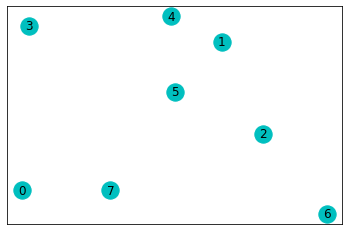

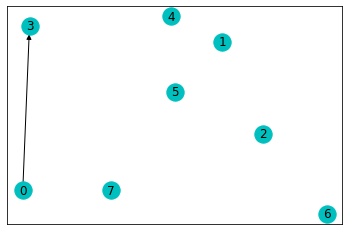

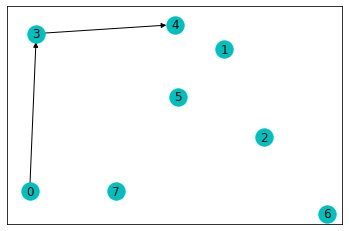

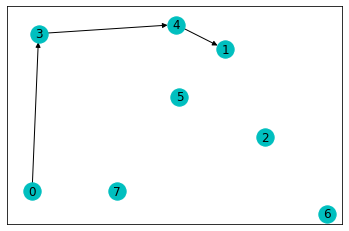

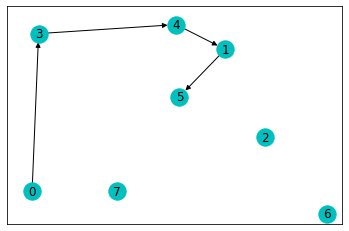

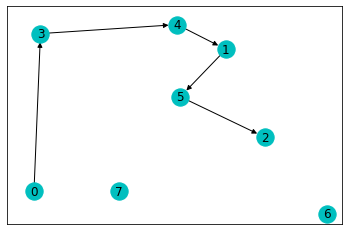

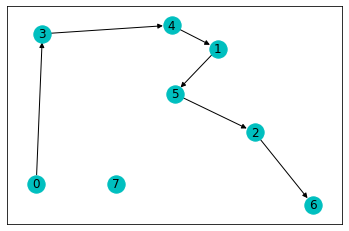

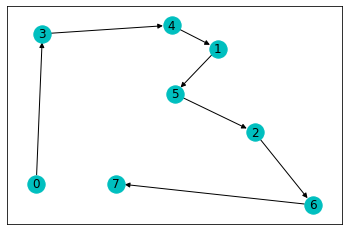

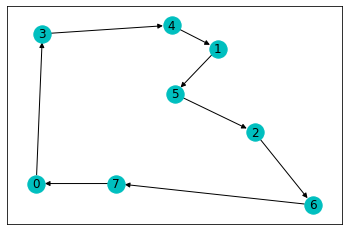

In [15]:
# 最短の巡回Route を表示する
for i in range(n):
    nx.draw_networkx(g, pos=pos, node_color='c')
    plt.show()
    g.add_edge(path[i], path[i + 1])
nx.draw_networkx(g, pos=pos, node_color='c')
plt.show()

for i in range(n):
    g.remove_edge(path[i], path[i + 1])

**全検索** は、倉庫の数が少ないうちは少ない計算時間で最短Route を導出できるが、要素の数が増えていくと、それに伴って計算時間が膨大になる。
そこで、効率的に最短Route を導出する方法を検討する必要がでてくる。

## Algorithm による問題の解き方を理解しよう

In [16]:
# for 文で和を求める

# n を100とする
n = 100
s = sum(i for i in range(1, n + 1))
print(f"和: {s}")

和: 5050


In [17]:
# 和の公式により求める
n = 10
s = (1 + n) * n // 2
print(f"和: {s}")

和: 55


In [19]:
# n が大きい場合
n = 10_000
s = (1 + n) * n // 2
print(f"和: {s}")

和: 50005000


Algorithm を工夫することで計算量を大きく圧縮することが可能になる。